<a href="https://colab.research.google.com/github/Pranayshukla0610/ML-projects-portfolio/blob/main/HSBC_Financial_Time_Series_Forecasting_and_Volatility_Analysis_using_ARIMA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
pip install pandas numpy matplotlib seaborn yfinance statsmodels pmdarima

In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import yfinance as yf
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

from pmdarima import auto_arima
import warnings
warnings.filterwarnings('ignore')

In [40]:
ticker = 'HSBC'
stock = yf.download(
    ticker,
    start='2020-01-01',
    end='2026-05-01'
)

[*********************100%***********************]  1 of 1 completed


In [41]:
stock.head()

Price,Close,High,Low,Open,Volume
Ticker,HSBC,HSBC,HSBC,HSBC,HSBC
Date,,,,,
2020-01-02,27.528954,27.528954,27.326177,27.368129,2046900
2020-01-03,27.102413,27.221285,26.997529,27.011514,1694800
2020-01-06,27.011517,27.025502,26.766782,26.766782,1807500
2020-01-07,26.808739,26.843700,26.724831,26.759792,2638800
2020-01-08,26.745808,26.836709,26.501076,26.501076,2299600


In [42]:
stock['Daily_Return'] = (
    stock['Close']
    .pct_change()
)

In [43]:
stock['Log_Return'] = np.log(
    stock['Close']/
    stock['Close'].shift(1)
)

In [44]:
log_returns = stock['Log_Return'].dropna()

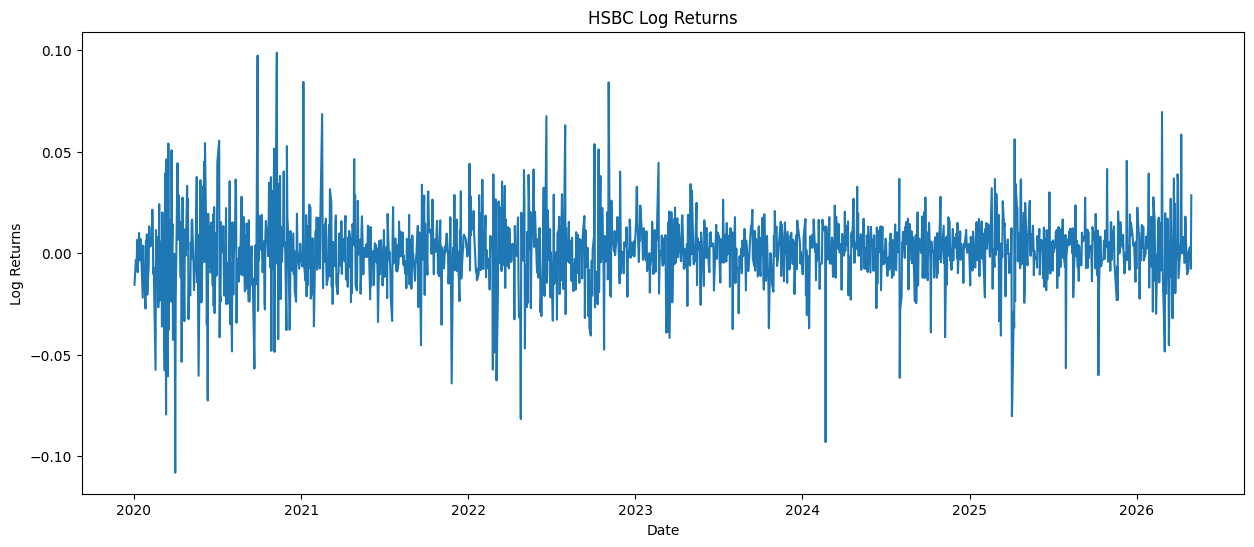

In [45]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x=log_returns.index,
    y=log_returns
)

plt.title('HSBC Log Returns')

plt.xlabel('Date')

plt.ylabel('Log Returns')

plt.show()

In [46]:
stock['volatility'] = (
    stock['Daily_Return']
    .rolling(30)
    .std()
)

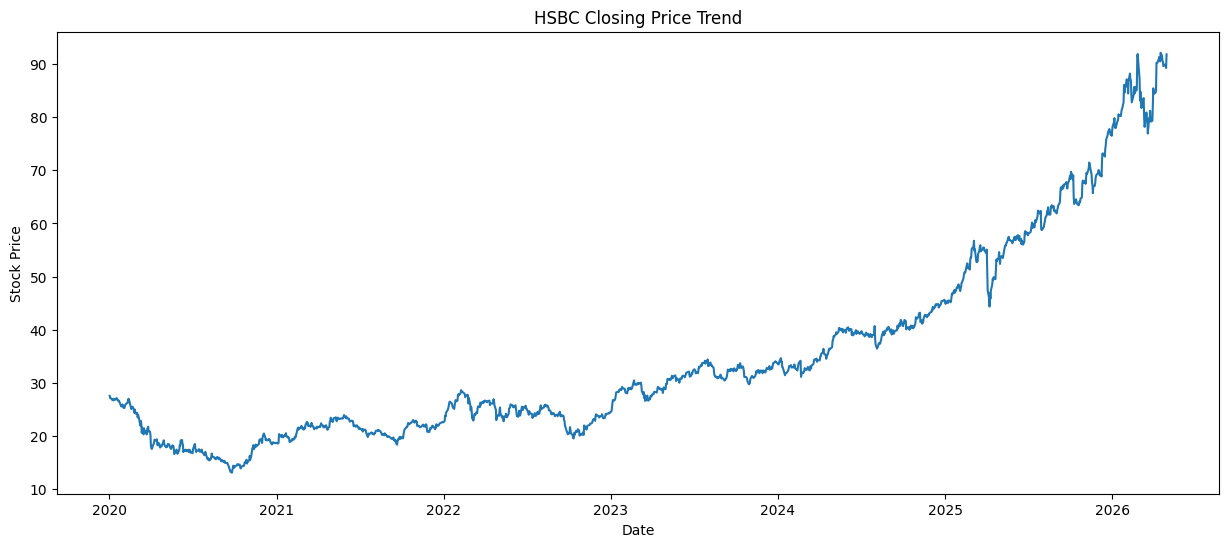

In [47]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x=stock.index,
    y=stock['Close'].squeeze()
)

plt.title('HSBC Closing Price Trend')

plt.xlabel('Date')

plt.ylabel('Stock Price')

plt.show()

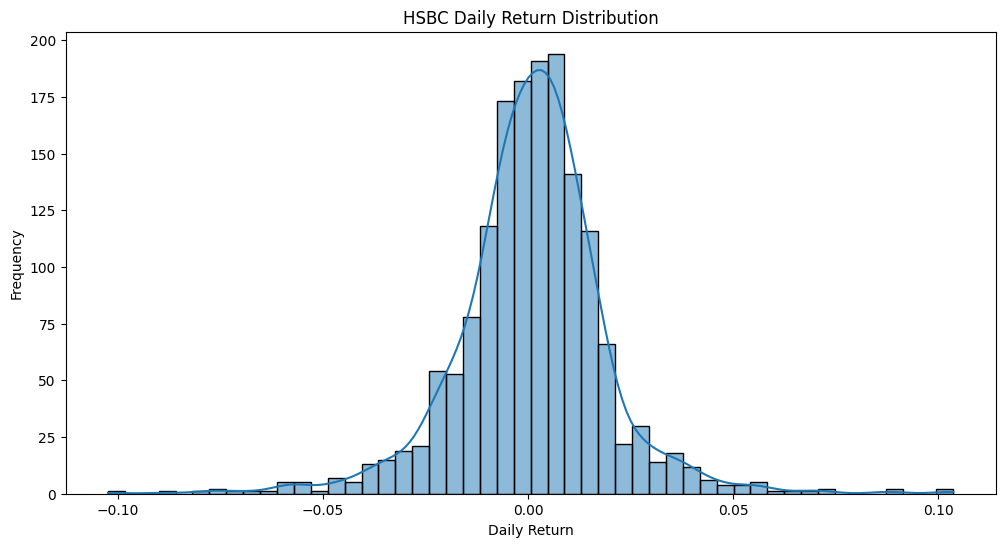

In [48]:
plt.figure(figsize=(12,6))

sns.histplot(
    stock['Daily_Return'].dropna(),
    bins=50,
    kde=True
)

plt.title('HSBC Daily Return Distribution')

plt.xlabel('Daily Return')

plt.ylabel('Frequency')

plt.show()

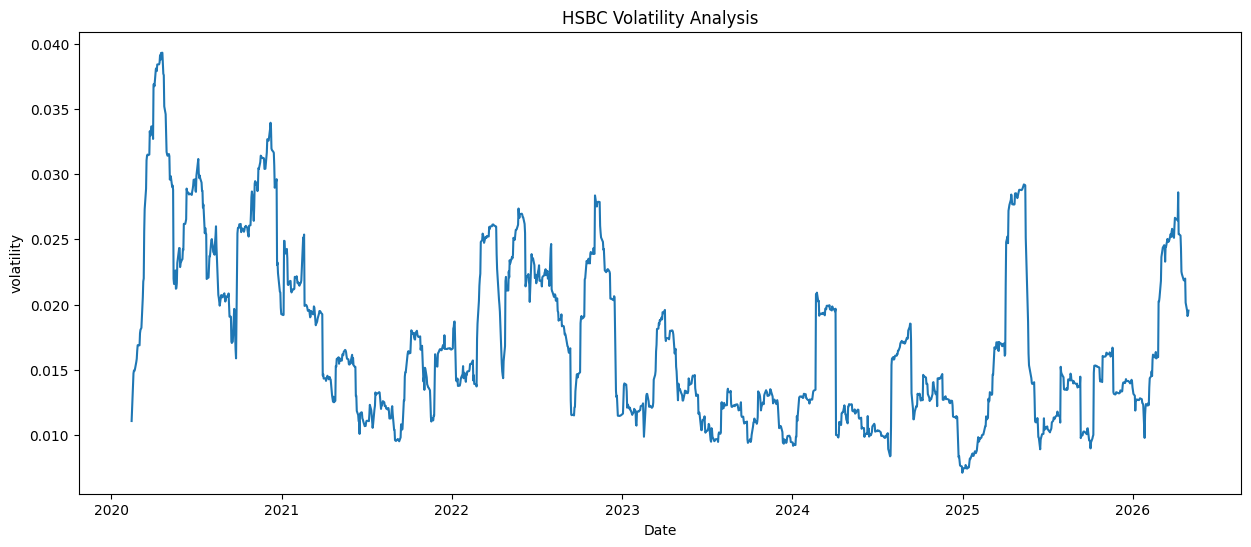

In [49]:
plt.figure(figsize=(15,6))

sns.lineplot(
    x=stock.index,
    y=stock['volatility']
)

plt.title('HSBC Volatility Analysis')

plt.show()

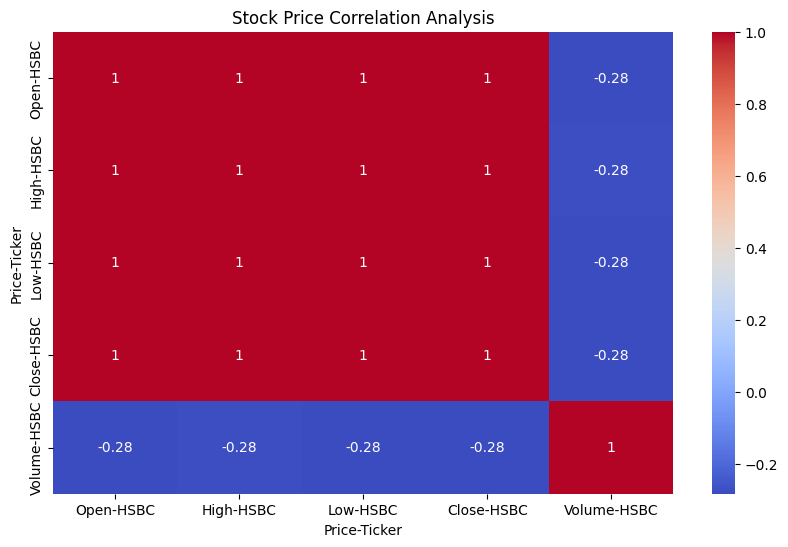

In [50]:
plt.figure(figsize=(10,6))

sns.heatmap(
    stock[
        ['Open','High','Low','Close','Volume']
    ].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Stock Price Correlation Analysis')

plt.show()

In [51]:
stock['MA_50'] = (
    stock['Close']
    .rolling(50)
    .mean()
)

In [52]:
stock['MA_200'] = (
    stock['Close']
    .rolling(200)
    .mean()
)

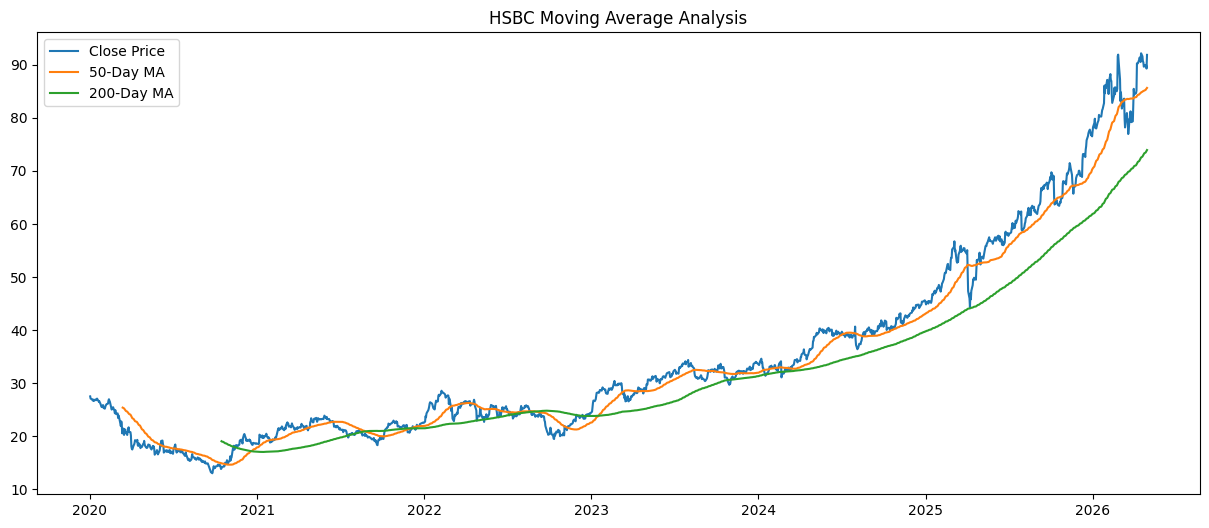

In [53]:
plt.figure(figsize=(15,6))

plt.plot(
    stock['Close'],
    label='Close Price'
)

plt.plot(
    stock['MA_50'],
    label='50-Day MA'
)

plt.plot(
    stock['MA_200'],
    label='200-Day MA'
)

plt.legend()

plt.title('HSBC Moving Average Analysis')

plt.show()

In [54]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(log_returns)

print("\nADF Statistic:", result[0])

print("p-value:", result[1])


ADF Statistic: -12.893787449608219
p-value: 4.392096944052731e-24


In [55]:
close_prices = (
    stock['Close']
    .dropna()
)

In [56]:
train_size = int(len(log_returns) * 0.8)

train = log_returns[:train_size]

test = log_returns[train_size:]

In [57]:
auto_model = auto_arima(
    train,
    seasonal=False,
    trace=True,
    suppress_warnings=True
)

print(auto_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0]             : AIC=-6543.914, Time=0.91 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-6539.894, Time=0.12 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-6548.265, Time=0.14 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-6547.530, Time=0.45 sec
 ARIMA(2,0,0)(0,0,0)[0]             : AIC=-6547.845, Time=0.44 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-6547.854, Time=0.95 sec
 ARIMA(2,0,1)(0,0,0)[0]             : AIC=-6545.626, Time=2.02 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-6547.082, Time=0.37 sec

Best model:  ARIMA(1,0,0)(0,0,0)[0]          
Total fit time: 5.412 seconds
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1271
Model:               SARIMAX(1, 0, 0)   Log Likelihood                3276.133
Date:                Wed, 13 May 2026   AIC                          -6548.265
Time:                       

In [58]:
model = ARIMA(
    train,
    order=(1,0,1)
)

model_fit = model.fit()

print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Log_Return   No. Observations:                 1271
Model:                 ARIMA(1, 0, 1)   Log Likelihood                3277.324
Date:                Wed, 13 May 2026   AIC                          -6546.648
Time:                        10:08:35   BIC                          -6526.058
Sample:                             0   HQIC                         -6538.914
                               - 1271                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004      0.000      0.870      0.384      -0.001       0.001
ar.L1         -0.4782      0.176     -2.713      0.007      -0.824      -0.133
ma.L1          0.3909      0.185      2.110      0.0

In [59]:
forecast = model_fit.forecast(
    steps=len(test)
)

In [60]:
mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

r2 = r2_score(
    test,
    forecast
)

print("\nARIMA MODEL PERFORMANCE")

print("MAE:", mae)

print("RMSE:", rmse)

print("R2:", r2)



ARIMA MODEL PERFORMANCE
MAE: 0.01207847733866004
RMSE: 0.017341880051791724
R2: -0.008919087950929327


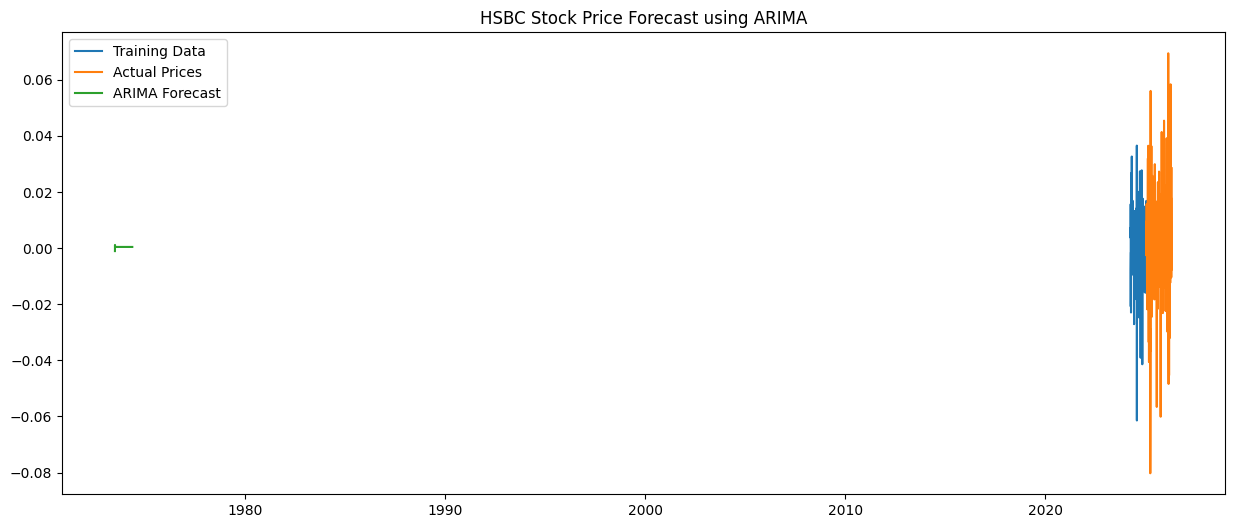

In [61]:
plt.figure(figsize=(15,6))

plt.plot(
    train[-200:],
    label='Training Data'
)

plt.plot(
    test,
    label='Actual Prices'
)

plt.plot(
    forecast,
    label='ARIMA Forecast'
)

plt.legend()

plt.title('HSBC Stock Price Forecast using ARIMA')

plt.show()

In [62]:
residuals = (
    test - forecast
)

The auto_arima process identified ARIMA(1,0,0) as the optimal model for forecasting HSBC log returns based on the lowest AIC value, indicating that the stock’s return behavior is primarily influenced by short-term lag dependencies rather than complex moving average structures. The negative AR coefficient suggests a mild mean-reverting behavior in HSBC’s returns, meaning that short-term positive movements are often followed by slight corrections, which is common in large banking stocks affected by institutional trading and market efficiency. In the manually fitted ARIMA(1,0,1) model, both the autoregressive and moving average components were statistically significant, indicating that past shocks and previous return movements contribute to short-term price behavior. The very small sigma² value reflects relatively low daily return variance, showing that HSBC’s stock returns are comparatively stable despite broader market fluctuations. The Ljung-Box test p-values above 0.05 suggest that the residuals do not exhibit significant autocorrelation, meaning the model successfully captured most sequential dependencies present in the data. However, the Jarque-Bera test and high kurtosis values indicate that the residuals are not normally distributed and contain fat tails, which is extremely common in financial markets where sudden shocks, economic crises, earnings surprises, and macroeconomic events create extreme price movements. The heteroskedasticity result further confirms that volatility is not constant over time, implying that HSBC experiences changing market risk levels across different economic periods. Overall, the analysis demonstrates that HSBC’s stock behavior exhibits characteristics typical of financial time-series data, including volatility clustering, short-term momentum effects, non-normal return distributions, and dynamic market uncertainty, highlighting both the usefulness and limitations of ARIMA models in real-world financial forecasting.